# Recusively splitting a binary tree until left with pure leaf nodes (data with only 1 type of class), and hence making a Decision Tree Classifier:

##### Implementing: [Video](https://www.youtube.com/watch?v=Okn4QkyTxe4)

### 1. Entropy ($H$):
- Entropy is a measure of impurity, disorder, or uncertainity in a dataset.
- High: Data belongs to multiple classes
- Low: Data comes majorly from a single class
$$H(S) = -\sum_{i=1}^{c}p_i\log_2(p_i)$$

- Where:
    * $c$ is the number of classes.
    * $p_i$ is the proportion(probability) of items belonging to class $i$ in set $S$.

### 2. Gini Impurity ($G$):

- Alternative to Entropy
- Prob of incorrectly classifying a random element.
- Faster than entropy as doesn't include logarithm
$$G(S) = 1 - \sum_{i=1}^{c}(p_i)^2$$
- Where:
    * $c$ is the number of classes
    * $p_i$ is the proportion of items of class $i$ in $S$

### 3. Information Gain ($IG$):

- Measure of reduction in entropy/gini impurity after dataset is splitted on an attribute
$$ IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v) $$
- Where:
    * $H(S)$ is the entropy of the parent dataset S before the split.
    * $A$ is the feature you are testing the split with.
    * $Values(A)$ are all children created by the split.
    * $|S_v|$ is the number of samples in node v.
    * $|S|$ is the total number of samples in S (Parent Node).
    * $H(S_v)$ is the entropy of the child node v.
- In much simpler terms:
$$ Information\ Gain = (Entropy\ of\ Parent) - (Weighted\ Average\ Entropy\ of\ Children)$$


Might also need gain ratio later.

### Reinventing Entropy in a Desert:
* Want a function that would take the state of a set, meaning the number of items of each class as an input and output a measure of purity
* The max purity is when all elements belong to the same class, let the impurity function output $0$ for that.
* The min purity is when elements are equally divided into 2 parts, let the imprity function output $1$ for that.
    * Entropy for a set equally distributed in 3 classes is inherently more impure than a set divided into 2 equal parts, as it contains more surprise. Hence the main formula for $H$ gives $$H_{max} = \log_2(3) \approx 1.58$$ for the former. 
* We also want: $$ Surprise(A\ and\ B) = Suprise(A) + Suprise(B)$$
* But: $$ P(A\ and \ B) = P(A) + P(B) \implies Must\ use \log()$$
* As $\log()$ is negative in $(0, 1) \implies -\log()$
* So, the final would be the weighted sum (Expected Value) of Surprises: 
    $$H(S) = -\sum_{i=1}^{c}p_i\log_2(p_i)$$


### Decision Tree Algo:
1. Try all possible features and thresholds at each node.
2. Calculate the information gain for each of these potential splits.
3. Choose the split that gives the highest information gain.
4. Repeat recursively until the tree is complete(or stopping criterion is met).

### Base condition for Recusion:
* Leaf nodes are sufficiently Pure (Actually pure would cause overfitting.)
    * For such a sufficiently Pure but impure node, majority voting is done.
* Other stopping criterion are met (e.g. max depth).

#### Note: You don't need NROMALIZATION for trees, EVEN FOR GRADIENT BOOSTED Trees, as inputs are always splitted on the basis of scale independed functions.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('../data/iris.csv')
data.sample(5)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
105,106,7.6,3.0,6.6,2.1,Iris-virginica
73,74,6.1,2.8,4.7,1.2,Iris-versicolor
93,94,5.0,2.3,3.3,1.0,Iris-versicolor
47,48,4.6,3.2,1.4,0.2,Iris-setosa
80,81,5.5,2.4,3.8,1.1,Iris-versicolor


In [3]:
# .Values allow us to index properly
X = data.drop(columns=['Id', 'Species']).values
y = data["Species"].values
X.shape, y.shape

((150, 4), (150,))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((120, 4), (120,), (30, 4), (30,))

In [5]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None, left=None, right=None, value=None):
        # A Node can either be a Decision Node or a Pure Node
        
        # Decision Node
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right

        # Leaf Node
        self.value = value

In [6]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        # Min Samples for splitting to occur
        self.min_samples_split=min_samples_split
        # Max depth for base case and preventing overfitting
        self.max_depth = max_depth

    def build_tree(self, X, y, curr_depth=0):
        n_samples, n_features = X.shape

        # For a Decision Node
        if n_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.best_split(X, y, n_features)
            
            # Returning a valid Decision Node
            if best_split["info_gain"] > 0:
                left_node = self.build_tree(best_split["left_X"], best_split["left_y"], curr_depth + 1)
                right_node = self.build_tree(best_split["right_X"], best_split["right_y"], curr_depth + 1)

                return Node(best_split["feature_idx"], best_split["threshold"], best_split["info_gain"], left_node, right_node)

        # Returning a Pure Node with Majority class
        classes, counts = np.unique(y, return_counts=True)
        leaf_value = classes[np.argmax(counts)]
        return Node(value=leaf_value)

    def best_split(self, X, y, n_feature):
        b_split = {
            "feature_idx": None,
            "threshold": None,
            "info_gain": -1,
            "left_X": None,
            "left_y": None,
            "right_X": None,
            "right_y": None
        }

        # Trying every possible feature x with every possible threshold to break and find resulting purity
        for feature_idx in range(n_feature):
            feature_values = X[:, feature_idx]
            thresholds = np.unique(feature_values)

            for threshold in thresholds:
                left_X, left_y, right_X, right_y = self.split(X, y, feature_idx, threshold) 

                if len(left_y) and len(right_y):
                    info_gain = self.information_gain(y, left_y, right_y)

                    if info_gain > b_split["info_gain"]:
                        b_split["feature_idx"] = feature_idx
                        b_split["threshold"] = threshold
                        b_split["info_gain"] = info_gain
                        b_split["left_X"] = left_X
                        b_split["left_y"] = left_y
                        b_split["right_X"] = right_X
                        b_split["right_y"] = right_y

        return b_split

    def split(self, X, y, feature_idx, threshold):
        left_X = X[X[:, feature_idx] <= threshold]
        left_y = y[X[:, feature_idx] <= threshold]
        right_X = X[X[:, feature_idx] > threshold]
        right_y = y[X[:, feature_idx] > threshold]
        return left_X, left_y, right_X, right_y

    def information_gain(self, parent_y, left_y, right_y):
        left_weight = len(left_y) / len(parent_y)
        right_weight = len(right_y) / len(parent_y)
        information_gain = self.entropy(parent_y) - (self.entropy(left_y) * left_weight) - (self.entropy(right_y) * right_weight)
        # information_gain = self.gini_impurity(parent_y) - (self.gini_impurity(left_y) * left_weight) - (self.gini_impurity(right_y) * right_weight)
        return information_gain

    def gini_impurity(self, y):
        g = 1
        class_labels = np.unique(y)
        for class_label in class_labels:
            p = len(y[class_label == y]) / len(y)
            g -= np.square(p)
        return g

    def entropy(self, y):
        e = 0
        class_labels = np.unique(y)
        for class_label in class_labels:
            p = len(y[class_label == y]) / len(y)
            e -= p * np.log2(p)
        return e

    def predict(self, X):
        predictions = [self.predict_class(row, self.root) for row in X]
        return predictions

    def predict_class(self, x, node):
        # Leaf Node: Base case
        if node.value is not None:
            return node.value
        # Decision Node
        feature_value = x[node.feature_idx] 
        if feature_value <= node.threshold:
            return self.predict_class(x, node.left)
        else:
            return self.predict_class(x, node.right)

    def fit(self, X, y):
        self.root = self.build_tree(X, y)


In [7]:
dt = DecisionTree(max_depth=3)
dt.fit(X_train, y_train)
predictions = dt.predict(X_test)

accuracy = np.mean(predictions==y_test) * 100
accuracy

np.float64(96.66666666666667)

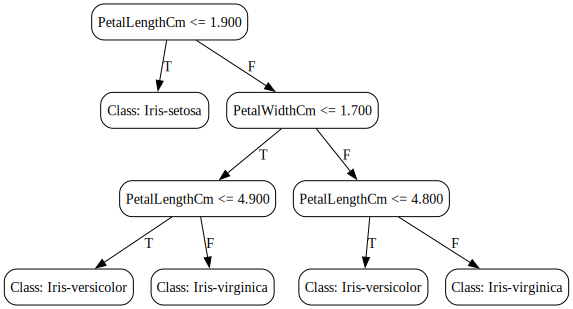

In [8]:
import graphviz
dot = graphviz.Digraph(node_attr={'shape': 'box', 'style': 'rounded'})
count = [0]

features = {
    0: 'SepalLengthCm',
    1: 'SepalWidthCm',
    2: 'PetalLengthCm',
    3: 'PetalWidthCm',
}

def get_graph(node):
    uid = str(count[0])
    count[0] += 1

    # Leaf Node
    if node.value is not None:
        dot.node(uid, f'Class: {node.value}')
        
    # Decision Node
    else:
        dot.node(uid, f'{features[node.feature_idx]} <= {node.threshold:.3f}')
        if node.left: dot.edge(uid, get_graph(node.left), "T")
        if node.right: dot.edge(uid, get_graph(node.right), "F")
    return uid
        
get_graph(dt.root)
dot

### Analyzing the same thing using XGBoost:

In [9]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=123)

xgb = XGBClassifier(max_depth=2).fit(X_train, y_train)
xgb_predictions = xgb.predict(X_test)
accuracy = np.mean(xgb_predictions==y_test)*100
accuracy

np.float64(96.66666666666667)

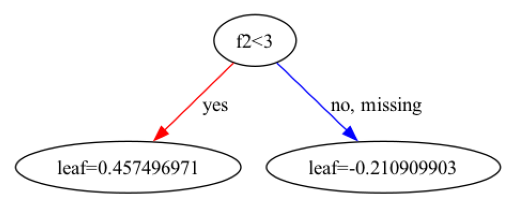

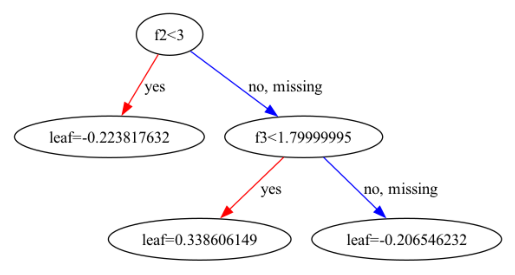

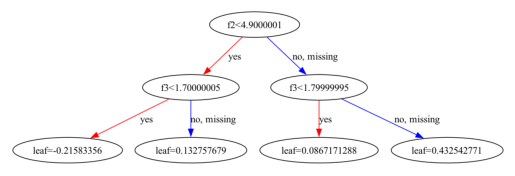

In [10]:
from matplotlib import pyplot as plt
from xgboost import plot_tree
%matplotlib inline

plot_tree(xgb, tree_idx=0)
plt.show()
plot_tree(xgb, tree_idx=1)
plt.show()
plot_tree(xgb, tree_idx=2)
plt.show()